# Feature Engineering/Nonlinear Regression and Regularization
Your Name: ...  
Date: ...

**Reminders:**


**Load Libraries (Don’t Forget to Run This)**  
In this assignment, we will use the Ames Housing price dataset from earlier homework assignments. This assignment is broken into two short problems:

**Problem 1: Feature Engineering.** We will perform feature engineering for this dataset to capture non-linear relationships between the various independent variables and Sales Price (the dependent variable).

**Problem 2: Regularization.** We demonstrate the power of regularization by intentionally adding in noise to our dataset so that linear regression (without regularization) grossly overfits. Then, we show that LASSO regularization allows us to remove most of the noisy terms and recover a model with much better out of sample performance.

In [1]:
# Run this cell
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.linear_model import Lasso, LassoCV
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import r2_score, accuracy_score, confusion_matrix, roc_auc_score, roc_curve, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
np.random.seed(25)

In [2]:
# Run this cell
def significance_stars(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    elif p < 0.1:
        return '.'
    else:
        return ''

def print_summary_with_stars(model):
    summary = model.summary2()
    coef_table = summary.tables[1].copy()

    coef_table['Signif'] = coef_table['P>|t|'].apply(significance_stars)

    numeric_columns = coef_table.select_dtypes(include=['float64', 'int64']).columns
    coef_table[numeric_columns] = coef_table[numeric_columns].round(4)
    coef_str = coef_table.to_string(index=True)

    # Determine max width
    other_texts = [
        "Regression Results",
        "Significance codes: '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1",
        f"R-squared: {model.rsquared:.4f}",
        f"Adjusted R-squared: {model.rsquared_adj:.4f}",
        f"F-statistic: {model.fvalue:.4f}",
        f"Prob (F-statistic): {model.f_pvalue:.4f}",
        f"Log-Likelihood: {model.llf:.4f}",
        f"No. Observations: {int(model.nobs)}",
        f"Df Model: {int(model.df_model)}",
        f"Df Residuals: {int(model.df_resid)}",
    ]
    max_width = max(
        max(len(line) for line in coef_str.splitlines()),
        *(len(t) for t in other_texts)
    )

    def line(char="="):
        return char * max_width

    # Print nicely formatted summary
    print(line("="))
    print("Regression Results")
    print(line("="))

    print(f"R-squared: {model.rsquared:.4f}")
    print(f"Adjusted R-squared: {model.rsquared_adj:.4f}")
    print(f"F-statistic: {model.fvalue:.4f}")
    print(f"Prob (F-statistic): {model.f_pvalue:.4f}")
    print(f"Log-Likelihood: {model.llf:.4f}")
    print(f"No. Observations: {int(model.nobs)}")
    print(f"Df Model: {int(model.df_model)}")
    print(f"Df Residuals: {int(model.df_resid)}")

    print(line("="))
    print("Coefficients:")
    print(line("-"))
    print(coef_str)
    print(line("="))
    print("Significance codes: '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1")
    print(line("="))


# Problem 1: Feature Engineering

Let’s load the same dataset `AmesSales_modified.csv` and
remind ourselves what the features are. The code below prints out the 11 independent variables as well as the dependent variable `SalePrice`.

In [3]:
data = pd.read_csv('AmesSales_modified.csv')
print(data.columns)

Index(['SalePrice', 'TotalRooms', 'Bedrooms', 'FullBath', 'HalfBath',
       'Fireplaces', 'LivArea', 'GarageArea', 'PoolArea', 'YearBuilt',
       'YearSold', 'BldgType'],
      dtype='object')


Let's perform a test/train split and then train a baseline linear
regression model. The code has been filled out for you below. Note that we chose a test/train split where `test_size=0.75`, meaning only 25% of our data is going into the training set, while 75% is going to our test set. This is **unconventional** and only done for educational purposes. Recall that a smaller training set makes models more prone to overfitting, which we will correct in the regularization portion of this assignment.

In [4]:
train_data, test_data = train_test_split(data, test_size=0.75)
print(train_data.shape)
print(test_data.shape)

(709, 12)
(2127, 12)


In [5]:
X = train_data.drop('SalePrice', axis=1)
y = train_data['SalePrice']

model = smf.ols(formula='SalePrice ~ TotalRooms + Bedrooms + FullBath + HalfBath + LivArea + Fireplaces + GarageArea + PoolArea + YearBuilt + YearSold + BldgType', data=train_data).fit()
print_summary_with_stars(model)

Regression Results
R-squared: 0.7894
Adjusted R-squared: 0.7852
F-statistic: 185.8541
Prob (F-statistic): 0.0000
Log-Likelihood: -8347.0080
No. Observations: 709
Df Model: 14
Df Residuals: 694
Coefficients:
------------------------------------------------------------------------------------------------
                         Coef.      Std.Err.        t   P>|t|        [0.025        0.975] Signif
Intercept          -11619.8235  1.804923e+06  -0.0064  0.9949 -3.555384e+06  3.532144e+06       
BldgType[T.2fmCon] -14534.3160  8.872646e+03  -1.6381  0.1019 -3.195476e+04  2.886132e+03       
BldgType[T.Duplex] -44288.1746  6.541342e+03  -6.7705  0.0000 -5.713137e+04 -3.144498e+04    ***
BldgType[T.Twnhs]  -20287.6731  6.839235e+03  -2.9664  0.0031 -3.371575e+04 -6.859601e+03     **
BldgType[T.TwnhsE] -16375.8421  4.693871e+03  -3.4888  0.0005 -2.559173e+04 -7.159952e+03    ***
TotalRooms           1050.1577  1.592524e+03   0.6594  0.5098 -2.076586e+03  4.176901e+03       
Bedrooms         

Let’s try to improve the R2 by analyzing a few of the variables.

## (a) Year Built

One of the significant variables above is `YearBuilt`. Let’s use the plot function to make a scatter plot between `YearBuilt` and `SalePrice`.

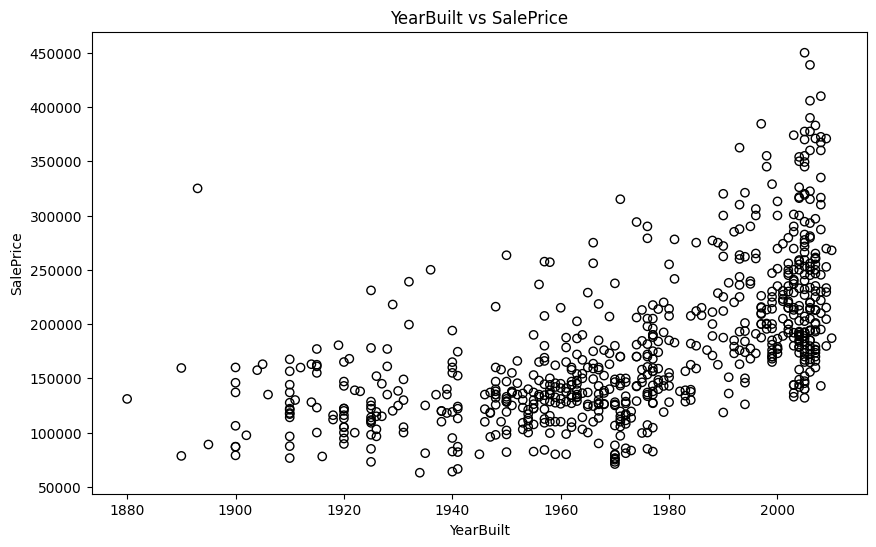

In [6]:
plt.figure(figsize=(10, 6))
plt.scatter(train_data['YearBuilt'], train_data['SalePrice'], edgecolors = 'black', facecolors = 'none')
plt.xlabel('YearBuilt')
plt.ylabel('SalePrice')
plt.title("YearBuilt vs SalePrice")
plt.show()

The relationship between `YearBuilt` and `SalePrice` looks non-linear. The data seems to have a gradual increase in the price up to 1970, after which there is a more prominent increase in price for properties built afterwards. Using this information, let’s add a feature `YearBuiltafter1970` so that our Linear Regression model can “bend” at 1970.

**Task.** Add to BOTH the training dataset and testing
the feature `YearBuiltafter1970`, which should be equal to
the number of years after 1970 (e.g., 2000 is 30 years after 1970), or 0 if the year is 1969 or earlier. You can do this using the `np.maximum` function.

In [7]:
# ### YOUR CODE HERE ###

train_data['YearBuiltafter1970'] = np.maximum(train_data["YearBuilt"] - 1970, 0)
test_data['YearBuiltafter1970'] = np.maximum(test_data["YearBuilt"] - 1970, 0)

# Code for showing the top 10 rows of the columns YearBuilt and YearBuiltafter1970
display(train_data[['YearBuilt','YearBuiltafter1970']].head(10).sort_index())
display(test_data[['YearBuilt','YearBuiltafter1970']].head(10).sort_index())

,YearBuilt,YearBuiltafter1970
376,1975,5
538,1963,0
738,1934,0
879,1928,0
1142,1976,6
1167,1966,0
1584,2005,35
1757,1962,0
1843,1968,0
2081,2002,32


,YearBuilt,YearBuiltafter1970
577,1967,0
663,1949,0
735,1987,17
777,1979,9
864,1950,0
1465,1914,0
1752,1983,13
1971,1920,0
2546,1966,0
2745,1924,0


Confirm from the code output above that your `YearBuiltafter1970` is correct.

Let’s create a new model `model2` using `train_data`, which now contains this extra variable.

In [8]:
model2 = smf.ols(formula='SalePrice ~ TotalRooms + Bedrooms + FullBath + HalfBath + LivArea + Fireplaces + GarageArea + PoolArea + YearBuilt + YearBuiltafter1970 + YearSold + BldgType', data=train_data).fit()
print_summary_with_stars(model2)

Regression Results
R-squared: 0.7962
Adjusted R-squared: 0.7918
F-statistic: 180.5423
Prob (F-statistic): 0.0000
Log-Likelihood: -8335.3611
No. Observations: 709
Df Model: 15
Df Residuals: 693
Coefficients:
-------------------------------------------------------------------------------------------------
                          Coef.      Std.Err.        t   P>|t|        [0.025        0.975] Signif
Intercept           492825.4337  1.779887e+06   0.2769  0.7820 -3.001792e+06  3.987443e+06       
BldgType[T.2fmCon]  -16584.1733  8.744765e+03  -1.8965  0.0583 -3.375358e+04  5.852381e+02      .
BldgType[T.Duplex]  -35740.5587  6.680005e+03  -5.3504  0.0000 -4.885603e+04 -2.262508e+04    ***
BldgType[T.Twnhs]   -15998.0698  6.791438e+03  -2.3556  0.0188 -2.933233e+04 -2.663808e+03      *
BldgType[T.TwnhsE]  -17031.9320  4.622736e+03  -3.6844  0.0002 -2.610818e+04 -7.955684e+03    ***
TotalRooms            -252.3676  1.590913e+03  -0.1586  0.8740 -3.375955e+03  2.871220e+03       
Bedrooms 

**Question 1:** The in-sample R2 increased from `model` to `model2`. Is this expected or surprising? Justify your answer.

***Answer 1:*** The in-sample R2 changed from 0.7894 to 0.7962 It is expected because adding variables always increases the R2 as it allows a better fit.

**Question 2:** Interpret the coefficients of `YearBuilt` and `YearBuiltAfter1970`. Can you provide a real-world explanation for why there is a difference before/after 1970?

***Answer 2:*** Before 1970, each additional later year increases the price by only about 573 dollars. After 1970, each additional year increases the price by about 573 + 839 = 1412. Diminishing cost.

## (b) Living Area

We hypothesize that there may be non-linear relationship between `LivArea` and `SalePrice`. Let's visualize the data by breaking `LivArea` into 5 buckets based on quantiles, that is: the bottom 20% of properties by living area, 20%-40%, 40%-60%, 60%-80% and 80%-100%.  

The code is provided for you below. `break_points` defines the 0, 20, 40, 60, 80 and 100th quantiles, while the function `pd.cut` divides the `LivArea` variable into buckets based on `break_points`.

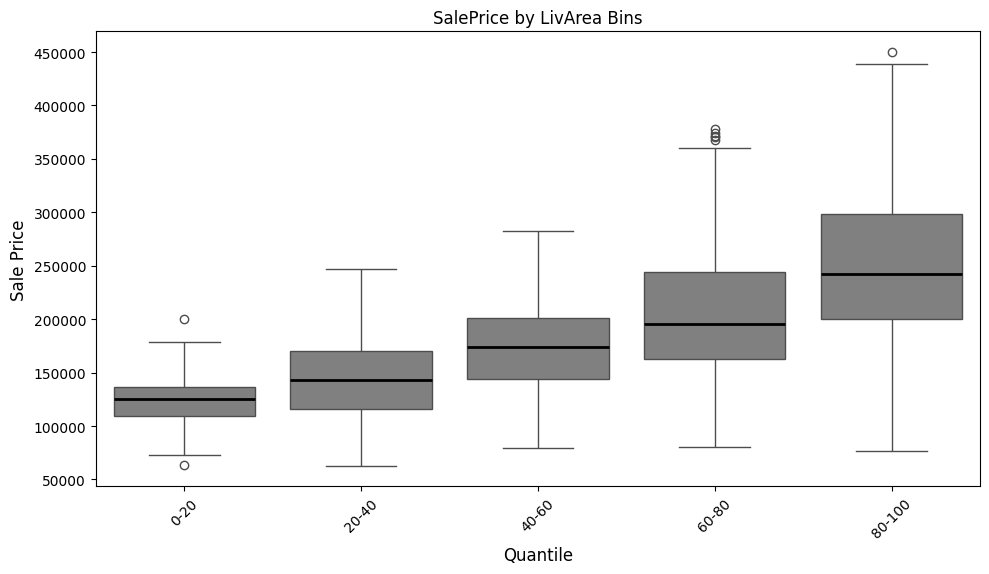

In [9]:
train_data_dummy = train_data.copy()
break_points = train_data_dummy['LivArea'].quantile([0, 0.2, 0.4, 0.6, 0.8, 1])

# Create bins using pd.cut
train_data_dummy['LivArea_Bins'] = pd.cut(
    train_data_dummy['LivArea'],
    bins=break_points,
    labels=['0-20', '20-40', '40-60', '60-80', '80-100'],
    include_lowest=True
)

# Create boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=train_data_dummy, x='LivArea_Bins', y='SalePrice',
            color='grey',
            medianprops=dict(color='black', linewidth=2))
plt.title("SalePrice by LivArea Bins")
plt.suptitle('')  # Remove the automatic title from pandas
plt.xlabel("Quantile", fontsize = 12)
plt.ylabel("Sale Price", fontsize = 12)
plt.xticks(rotation=45, fontsize=10)
plt.tight_layout()
plt.show()

The thick black line in each box represents the median sale price of
properties in that bucket. We notice a trend in the median of each bucket, where there seems to be 2 “bends”, one between 0-20 and 20-40 and another between 60-80 and 80-100. We choose to augment `LivArea` with higher order polynomial features of degree 2 and 3.

**Task.** Create the features `LivArea2` and `LivArea3` to both `train_data` as well as `test_data`. `LivArea2` should be `LivArea` raised to the 2nd power, while `LivArea3` is `LivArea` raised to the 3rd power.

In [10]:
### YOUR CODE HERE ###

test_data['LivArea2'] = test_data['LivArea']**2
test_data['LivArea3'] = test_data['LivArea']**3

train_data['LivArea2'] = train_data['LivArea']**2
train_data['LivArea3'] = train_data['LivArea']**3

### Code below is provided for displaying the additional columns added
display(train_data[['LivArea', 'LivArea2', 'LivArea3']].head(5).sort_index())
display(test_data[['LivArea', 'LivArea2', 'LivArea3']].head(5).sort_index())

,LivArea,LivArea2,LivArea3
376,1621,2627641,4259406061
879,1981,3924361,7774159141
1167,1165,1357225,1581167125
1584,2541,6456681,16406426421
2081,1729,2989441,5168743489


,LivArea,LivArea2,LivArea3
735,1200,1440000,1728000000
777,1535,2356225,3616805375
1752,884,781456,690807104
1971,1111,1234321,1371330631
2745,1669,2785561,4649101309


Let's train a model `model3` and calculate its R2.

In [11]:
model3 = smf.ols(formula='SalePrice ~ TotalRooms + Bedrooms + FullBath + HalfBath + LivArea + LivArea2 + LivArea3 + Fireplaces + GarageArea + PoolArea + YearBuilt + YearBuiltafter1970 + YearSold + BldgType', data=train_data).fit()
print_summary_with_stars(model3)

Regression Results
R-squared: 0.8019
Adjusted R-squared: 0.7970
F-statistic: 164.4889
Prob (F-statistic): 0.0000
Log-Likelihood: -8325.4662
No. Observations: 709
Df Model: 17
Df Residuals: 691
Coefficients:
------------------------------------------------------------------------------------------------
                          Coef.      Std.Err.       t   P>|t|        [0.025        0.975] Signif
Intercept           749014.8194  1.758719e+06  0.4259  0.6703 -2.704060e+06  4.202089e+06       
BldgType[T.2fmCon]  -14605.9393  8.651873e+03 -1.6882  0.0918 -3.159305e+04  2.381174e+03      .
BldgType[T.Duplex]  -35999.4926  6.600904e+03 -5.4537  0.0000 -4.895973e+04 -2.303926e+04    ***
BldgType[T.Twnhs]   -15167.2720  6.711410e+03 -2.2599  0.0241 -2.834447e+04 -1.990070e+03      *
BldgType[T.TwnhsE]  -16296.2267  4.578421e+03 -3.5594  0.0004 -2.528551e+04 -7.306940e+03    ***
TotalRooms             -53.6619  1.571808e+03 -0.0341  0.9728 -3.139755e+03  3.032431e+03       
Bedrooms         

**Question 3:** How does this R2 compare to that of `model2`? Would you say `LivArea2` and `LivArea3` are useful variables to add?

***Answer 3:*** The in-sample R2 increases and becomes 0.8019. The added variables are significant.

## (c) Hypothetical Feature Engineering

In each of the following questions, we will pose a hypothetical scenario and ask you a question related to feature engineering. Note that the observations are made up and do not necessarily hold in the real dataset.

**Question 4:** You examine how `SalePrice` changes with
the number of `Fireplaces`, a very significant variable in the regression model. You notice that homes with 0 fireplace, 1 fireplace, 2 fireplaces and 3 fireplaces have an average `SalePrice` given in the table below. The relationship between fireplace and sale price is clearly non-linear.

In [12]:
fireplace_table = train_data.groupby('Fireplaces')['SalePrice'].mean().reset_index()
fireplace_table['SalePrice'] = fireplace_table['SalePrice'].round(2)
fireplace_table.columns = ['Number of Fireplaces', 'SalePrice']
display(fireplace_table.style.hide(axis='index').format({'SalePrice': '${:,.2f}'}))

Number of Fireplaces,SalePrice
0,"$143,806.74"
1,"$211,343.58"
2,"$220,998.40"
3,"$202,000.00"


**Using this information, propose two ways that you could help Linear Regression capture this non-linearity. (Hint: one of the ways is from Lecture 2).**

***Answer 4:*** Quadratic term, or categorical variable.

**Question 5:** Your real-estate friend tells you a secret from the trade: there is a strong connection between `Bedroom`, `LivArea` and `SalePrice`. For properties with a small number of bedrooms, each additional square foot of living area has a large impact on the sale price of the unit. On the other hand, for properties with a larger number of bedrooms, the impact of each additional square foot of living area is much smaller.

**Using this information, propose a new feature to add to the dataset.**

***Answer 5:*** We could introduce alpha = LivArea/(Bedrooms+1) for instance. For a low number of bedrooms, the impact of `LivArea` on alpha will be much larger than when the number of bedrooms is higher.

**Question 6:** While the dataset contains the variables for the number of full and half bathrooms, it is customary to simply include the total number of bathrooms as Full Bath + 0.5 * Half Bath. (e.g., a property with 2 full baths and 1 half bath is typically said to have 2.5 total bath). Your friend says you should add the feature `TotalBaths` to your dataset, equal to `FullBath` plus 0.5 times `HalfBath`. Your friend says that doing so will increase the in-sample R2. Do you agree or disagree with your friend? Why?


***Answer 6:*** Disagree. Not increasing the power of linear regresssion. Indeed, the added feature is completely correlated with the ones in the dataset.

## (d) Calculating OSR<sup>2</sup>


Let’s test the out-of-sample performance of all 3 models

In [13]:
def calculate_r2(predictions):
  sse = np.sum((train_data['SalePrice'] - predictions) **2)
  sst = np.sum((train_data['SalePrice'] - np.mean(train_data['SalePrice'])) ** 2)
  return 1 - (sse/sst)
def calculate_osr2(predictions):
  sse = np.sum((test_data['SalePrice'] - predictions)**2)
  sst = np.sum((test_data['SalePrice'] - np.mean(train_data['SalePrice'])) ** 2)
  return 1 - (sse/sst)

pd.DataFrame({
    'name': ['model', 'model2', 'model3'],
    'r2': [calculate_r2(model.predict(train_data)),
           calculate_r2(model2.predict(train_data)),
           calculate_r2(model3.predict(train_data))],
    'osr2': [calculate_osr2(model.predict(test_data)),
             calculate_osr2(model2.predict(test_data)),
             calculate_osr2(model3.predict(test_data))]
})


,name,r2,osr2
0,model,0.789439,0.738232
1,model2,0.796244,0.750281
2,model3,0.801853,0.762150


**Question 7:** Comment on the R2 and OSR2 performance above. Would you say our feature engineering was successful?

***Answer 7:*** Yes. The increase in R2 is reflected by the out-of-sample performance.

# Problem 2: Regularization

We demonstrate the power of regularization by intentionally adding in noise to our dataset so that linear regression (without regularization) grossly overfits. Then, we show that LASSO regularization allows us to remove most of the noisy terms and recover a model with much better out of sample performance.

In particular, we will first inject an extra 100 (!!) columns into `train_data` and `test_data`, each of which will be a uniform random number between 0 and 1.Clearly, these variables have nothing to do with `SalePrice` and are purely noise added for the sake of instruction. We will see how LASSO is able to remove this noise and recover the strong OSR2 we saw in Assignment 2.

## (a) Adding the Noise

We add in 100 noisy features, called `noise_1`, `noise_2`, …, `noise_100` to our dataset. Our training dataset now has 115 features, the 1 dependent variable + 11 original variables + 3 variables we feature engineered + 100 features that are pure noise.

In [14]:
n_noise = 100
for i in range(1, n_noise+1):
  train_data[f"noise_{i}"] = np.random.uniform(size=len(train_data))
  test_data[f"noise_{i}"] = np.random.uniform(size=len(test_data))

print(train_data.shape)

(709, 115)


/tmp/ipython-input-187099005.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_data[f"noise_{i}"] = np.random.uniform(size=len(train_data))
/tmp/ipython-input-187099005.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_data[f"noise_{i}"] = np.random.uniform(size=len(test_data))
/tmp/ipython-input-187099005.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=

Let's take a peek at a few columns of our dataset. We see that `noise_1`, `noise_2` and `noise_100` are just pure nonsense.

In [15]:
display(train_data[['SalePrice', 'LivArea', 'Bedrooms', 'noise_1', 'noise_2', 'noise_100']].head(6).sort_index())

,SalePrice,LivArea,Bedrooms,noise_1,noise_2,noise_100
376,213000.0,1621,3,0.188861,0.522820,0.963359
879,135000.0,1981,4,0.568140,0.344509,0.982127
1167,174900.0,1165,3,0.240845,0.143556,0.338872
1584,349265.0,2541,4,0.418640,0.140982,0.140796
1843,126000.0,1560,4,0.937343,0.057625,0.987186
2081,200000.0,1729,3,0.249723,0.592419,0.870839


Let’s see how the in-sample performance of a linear regression model
changes.

In [16]:
features = [col for col in train_data.columns if col != 'SalePrice']
formula = 'SalePrice ~ ' + ' + '.join(features)
model_with_noise = smf.ols(formula = formula, data=train_data).fit()
print_summary_with_stars(model_with_noise)

Regression Results
R-squared: 0.8289
Adjusted R-squared: 0.7950
F-statistic: 24.4738
Prob (F-statistic): 0.0000
Log-Likelihood: -8273.4071
No. Observations: 709
Df Model: 117
Df Residuals: 591
Coefficients:
------------------------------------------------------------------------------------------------
                          Coef.      Std.Err.       t   P>|t|        [0.025        0.975] Signif
Intercept           284845.1492  1.910573e+06  0.1491  0.8815 -3.467493e+06  4.037183e+06       
BldgType[T.2fmCon]  -19066.5595  9.371289e+03 -2.0346  0.0423 -3.747164e+04 -6.614788e+02      *
BldgType[T.Duplex]  -34513.7105  7.099041e+03 -4.8617  0.0000 -4.845613e+04 -2.057129e+04    ***
BldgType[T.Twnhs]   -11152.9637  7.359934e+03 -1.5154  0.1302 -2.560777e+04  3.301844e+03       
BldgType[T.TwnhsE]  -16446.3219  4.988982e+03 -3.2965  0.0010 -2.624461e+04 -6.648030e+03     **
TotalRooms            1472.5023  1.700868e+03  0.8657  0.3870 -1.867979e+03  4.812984e+03       
Bedrooms         

Wow, the in-sample R2 is pretty good! But what about the OSR2?

In [17]:
print(calculate_osr2(model_with_noise.predict(test_data)).round(4))

0.7232


**Question 8:** Explain in your own words what overfitting means. Why does adding these 100 noise features lead to significant overfitting? What would you expect would happen if you added 1000 noise features instead?

***Answer 8:*** Overfitting happens when a model learns patterns that exist in the training data but do not generalize well to new, unseen data. The model becomes too complex and starts to learn the noise rather than the true relationships between the dependent and independent variables. Adding these 100 noise features lead the model to find patterns in these completely irrelevant features. If we increase the number of noise features to 1000, there would be even more overfitting.

## (b) Regularization with Particular $\lambda$ Values

We now use Linear Regression with LASSO regularization to build linear regression models that select a subset of these 115 variables. First, we process our data so that `X_train` and `X_test` only have the independent variables and `y_train` and `y_test` contain the dependent variable.

In [18]:
X_train = pd.get_dummies(train_data.drop('SalePrice', axis=1), drop_first = True)
y_train = train_data['SalePrice']

X_test = pd.get_dummies(test_data.drop('SalePrice', axis=1), drop_first = True)
y_test = test_data['SalePrice']

**Task.** Build 3 LASSO models with $\lambda$ = 100, $\lambda$ = 3000 and $\lambda$ = 10,000 respectively. For each choice of $\lambda$, build a linear regression model with LASSO regularization.

In [19]:
### YOUR CODE HERE ###
lasso_model_100   = Lasso(alpha=100).fit(X_train, y_train)
lasso_model_3000  = Lasso(alpha=3000).fit(X_train, y_train)
lasso_model_10000 = Lasso(alpha=10000).fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.123e+11, tolerance: 3.316e+08
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.201e+11, tolerance: 3.316e+08
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.449e+11, tolerance: 3.316e

We report the following metrics.
*   In-Sample R2
*   Out-of-Sample R2
*   Number of non-zero coefficients (out of 115)  

We also compare with `model_with_noise`, which is linear regression without regularization. This is equivalent to choosing $\lambda$ = 0 in LASSO.






In [20]:
def calculate_r2(y_true, y_pred):
    sse = np.sum((y_true - y_pred) ** 2)
    sst = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (sse / sst)

def calculate_osr2(y_train_true, y_test_true, y_test_pred):
    sse = np.sum((y_test_true - y_test_pred) ** 2)
    sst = np.sum((y_test_true - np.mean(y_train_true)) ** 2)
    return 1 - (sse / sst)

results = pd.DataFrame({
    'model_name': ['No Regularization (Lambda: 0)', 'Lambda: 100', 'Lambda: 3000', 'Lambda: 10000'],
    'r2': [
        calculate_r2(y_train, model_with_noise.predict(train_data)),
        calculate_r2(y_train, lasso_model_100.predict(X_train)),
        calculate_r2(y_train, lasso_model_3000.predict(X_train)),
        calculate_r2(y_train, lasso_model_10000.predict(X_train)),
    ],
    'osr2': [
        calculate_osr2(y_train, y_test, model_with_noise.predict(test_data)),
        calculate_osr2(y_train, y_test, lasso_model_100.predict(X_test)),
        calculate_osr2(y_train, y_test, lasso_model_3000.predict(X_test)),
        calculate_osr2(y_train, y_test, lasso_model_10000.predict(X_test)),
    ],
    'non_zero_coefficients': [
        X_train.shape[1],
        np.sum(lasso_model_100.coef_   != 0),
        np.sum(lasso_model_3000.coef_  != 0),
        np.sum(lasso_model_10000.coef_ != 0),
    ]
})

display(results.style.hide(axis='index'))

model_name,r2,osr2,non_zero_coefficients
No Regularization (Lambda: 0),0.828916,0.723227,117
Lambda: 100,0.825621,0.711136,88
Lambda: 3000,0.767376,0.723312,10
Lambda: 10000,0.738441,0.704254,7


**Question 9:** In your own words, explain why a larger choice of $\lambda$ leads to a Linear Regression model with fewer non-zero coefficients (i.e., fewer variables selected)

***Answer 9:*** A higher $\lambda$ encourages more coefficients to shrink toward zero in the LASSO model. This results in fewer non-zero coefficients

## (c) Cross Validation to Find the Optimal $\lambda$

Use cross-validation `LassoCV` to choose the optimal value of $\lambda$. Here, use 5-fold cross validation on values of $\lambda$ from 1000 to 10000 in increments of 200 (i.e., `np.arange(1000, 10000, 200)`). Print out the best value of $\lambda$ using `lasso_cv.alpha_`.

In [21]:
### YOUR CODE HERE (print lasso_cv.alpha_)###

# use this warnings.filterwarnings to make the run silent
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

alphas = np.arange(1000, 10000, 200)
lasso_cv = LassoCV(alphas = alphas, cv = 5, max_iter = 10000).fit(X_train, y_train)
print("Best alpha (lambda):", lasso_cv.alpha_)

Best alpha (lambda): 1000


Construct a model called `lasso_model_optimal` using the optimal value of $\lambda$ you got above.

In [22]:
### YOUR CODE HERE ###
lasso_model_optimal = Lasso(alpha = lasso_cv.alpha_, max_iter = 10000).fit(X_train, y_train)

### The code below generates metrics for lasso_model_optimal ###

results = pd.DataFrame({
    'model_name': ['No Regularization (Lambda: 0)', 'Lambda: 100', 'Lambda: 3000', 'Lambda: 10000', 'Lambda Optimal'],
    'r2': [
        calculate_r2(y_train, model_with_noise.predict(train_data)),
        calculate_r2(y_train, lasso_model_100.predict(X_train)),
        calculate_r2(y_train, lasso_model_3000.predict(X_train)),
        calculate_r2(y_train, lasso_model_10000.predict(X_train)),
        calculate_r2(y_train, lasso_model_optimal.predict(X_train)),
    ],
    'osr2': [
        calculate_osr2(y_train, y_test, model_with_noise.predict(test_data)),
        calculate_osr2(y_train, y_test, lasso_model_100.predict(X_test)),
        calculate_osr2(y_train, y_test, lasso_model_3000.predict(X_test)),
        calculate_osr2(y_train, y_test, lasso_model_10000.predict(X_test)),
        calculate_osr2(y_train, y_test, lasso_model_optimal.predict(X_test)),
    ],
    'non_zero_coefficients': [
        X_train.shape[1],
        np.sum(lasso_model_100.coef_   != 0),
        np.sum(lasso_model_3000.coef_  != 0),
        np.sum(lasso_model_10000.coef_ != 0),
        np.sum(lasso_model_optimal.coef_ != 0),
    ]
})

display(results.style.hide(axis='index'))


model_name,r2,osr2,non_zero_coefficients
No Regularization (Lambda: 0),0.828916,0.723227,117
Lambda: 100,0.825621,0.711136,88
Lambda: 3000,0.767376,0.723312,10
Lambda: 10000,0.738441,0.704254,7
Lambda Optimal,0.788195,0.760685,13


**Question 10:** Comment on the performance of `lasso_model_optimal` shown in the “Lambda Optimal” row above.

***Answer 10:*** This model performs the best in terms of osr2 and only uses 13 non-zero coefficients.

Examine the coefficients of the optimal model by running the code
below.

In [23]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

coef_table = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": lasso_model_optimal.coef_
})

coef_table

,feature,coefficient
0,TotalRooms,-192.947286
1,Bedrooms,-9007.142728
2,FullBath,-0.000000
3,HalfBath,-10295.694815
4,Fireplaces,12898.438380
5,LivArea,-67.507273
6,GarageArea,59.925806
7,PoolArea,61.138185
8,YearBuilt,405.651348
9,YearSold,-448.000874


**Question 11:** Out of the 100 pure noise variables that we added, how many does this optimal LASSO model assign a non-zero coefficient to? Comment on how this highlights the ability for LASSO to remove non-informative variables.

***Answer 11:*** None of the 100 noise variables are selected. This means that LASSO is good at removing non-informative variables from the regression model.